# Analise Macroeconomica — Global

Analise do cenario macroeconomico global com dados reais do FRED e Yahoo Finance.

Fontes:
- **FREDFetcher**: Fed Funds Rate, Treasury 10y, VIX, CPI US, yield curve spread
- **YahooFinanceFetcher**: DXY (Dollar Index), commodities globais
- **CurrencyAnalyzer**: carry trade Selic-Fed, DXY

**Nota**: Requer `FRED_API_KEY` no `.env` para os indicadores do Fed.
DXY via Yahoo Finance nao requer autenticacao.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

FRED_OK = bool(os.getenv("FRED_API_KEY"))
print(f"FRED API key configurada: {FRED_OK}")
if not FRED_OK:
    print("Algumas secoes dependerao da FRED_API_KEY. Obtenha em:")
    print("https://fred.stlouisfed.org/docs/api/api_key.html")

FRED API key configurada: False
Algumas secoes dependerao da FRED_API_KEY. Obtenha em:
https://fred.stlouisfed.org/docs/api/api_key.html


## 1. Federal Reserve — Politica Monetaria dos EUA

In [2]:
if FRED_OK:
    from carteira_auto.data.fetchers import FREDFetcher
    fred = FREDFetcher()

    # Fed Funds Rate
    fed_funds = fred.get_fed_funds_rate()
    print(f"Fed Funds Rate atual: {fed_funds['value'].iloc[-1]:.2f}%")

    # Treasury 10 anos
    t10y = fred.get_treasury_10y()
    print(f"Treasury 10y: {t10y['value'].iloc[-1]:.2f}%")

    # VIX (indice de volatilidade)
    vix = fred.get_vix()
    print(f"VIX: {vix['value'].iloc[-1]:.1f}")

    # Yield curve spread (10y - 2y)
    spread = fred.get_yield_curve_spread()
    print(f"Yield curve spread (10y-2y): {spread['value'].iloc[-1]:.2f}%")
    if spread['value'].iloc[-1] < 0:
        print("  ALERTA: Curva invertida — historicamente sinal de recessao")
else:
    print("Secao requer FRED_API_KEY")

Secao requer FRED_API_KEY


In [3]:
if FRED_OK:
    # Visualizar Fed Funds e Treasury 10y
    fig, ax = plt.subplots()
    ax.plot(fed_funds["date"], fed_funds["value"], label="Fed Funds", linewidth=2)
    ax.plot(t10y["date"], t10y["value"], label="Treasury 10y", linewidth=2)
    ax.set_title("Fed Funds vs Treasury 10y")
    ax.set_ylabel("% a.a.")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
if FRED_OK:
    # VIX — Índice de medo do mercado
    fig, ax = plt.subplots()
    ax.plot(vix["date"], vix["value"], linewidth=1.5, color="#d62728")
    ax.fill_between(vix["date"], vix["value"], alpha=0.1, color="#d62728")
    ax.axhline(y=20, color="green", linestyle="--", alpha=0.5, label="Normal (<20)")
    ax.axhline(y=30, color="orange", linestyle="--", alpha=0.5, label="Medo elevado (>30)")
    ax.axhspan(30, vix["value"].max() * 1.1, alpha=0.05, color="red")
    ax.set_title("VIX — Índice de Volatilidade (Medo)")
    ax.set_ylabel("Índice")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
if FRED_OK:
    # Yield Curve Spread (10y - 2y) — sinal de recessão
    fig, ax = plt.subplots()
    cores_yc = ["#2ca02c" if v >= 0 else "#d62728" for v in spread["value"]]
    ax.fill_between(spread["date"], spread["value"], 0, 
                    where=[v >= 0 for v in spread["value"]], alpha=0.3, color="#2ca02c", label="Normal")
    ax.fill_between(spread["date"], spread["value"], 0,
                    where=[v < 0 for v in spread["value"]], alpha=0.3, color="#d62728", label="Invertida (recessão)")
    ax.plot(spread["date"], spread["value"], linewidth=1.5, color="black")
    ax.axhline(y=0, color="black", linewidth=1)
    ax.set_title("Yield Curve Spread (10y - 2y) — Sinal de Recessão")
    ax.set_ylabel("Spread (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2. Dollar Index (DXY)

O DXY mede a forca do dolar contra uma cesta de moedas.
Buscado via Yahoo Finance (ticker DX-Y.NYB).

/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/venv/lib/python3.12/site-packages/yfinance/utils.py:167: DeprecationWarning: enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)
  warnings.warn("enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)", DeprecationWarning)


2026-03-26 18:31:28 INFO     carteira_auto.data.fetchers.yahoo_fetcher: Modo debug do yfinance  ]8;id=56373;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=367741;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#49\49]8;;\
                             ativado                                                                               

                    INFO     carteira_auto.data.fetchers.yahoo_fetcher: YahooFinanceFetcher     ]8;id=909732;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=723490;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#39\39]8;;\
                             inicializado: workers=12, timeout=30s, retries=3                                      

[*********************100%***********************]  1 of 1 completed


2026-03-26 18:31:36 INFO     carteira_auto.data.fetchers.yahoo_fetcher: Dados históricos       ]8;id=740605;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=63271;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#117\117]8;;\
                             obtidos para ['DX-Y.NYB']: 306 registros                                              

DXY atual: 99.93
DXY 12m atras: 104.55
Variacao 12m: -4.4%


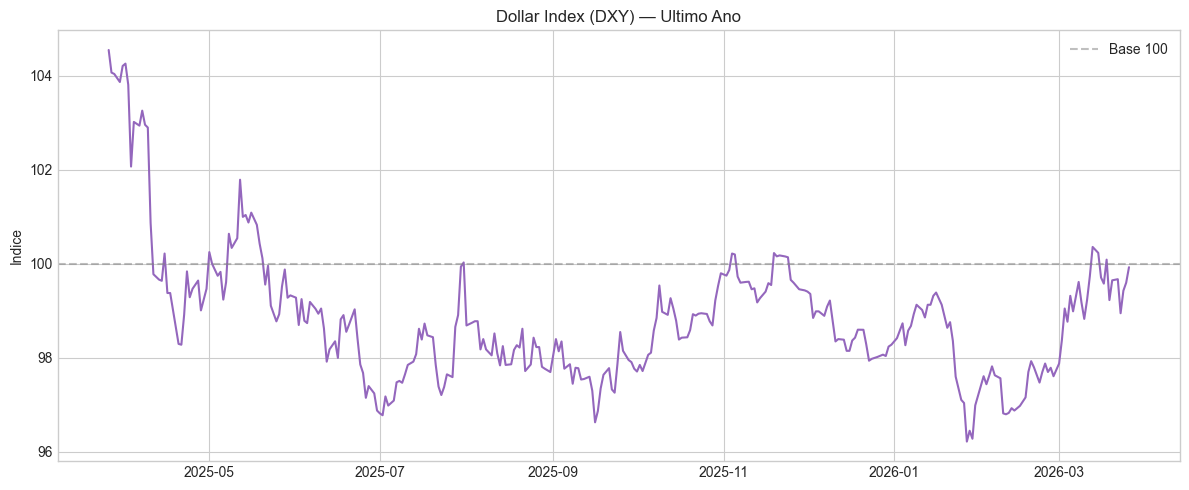

In [4]:
from carteira_auto.data.fetchers import YahooFinanceFetcher

yahoo = YahooFinanceFetcher()

# DXY historico (1 ano)
dxy = yahoo.get_historical_price_data(["DX-Y.NYB"], period="1y")

if not dxy.empty:
    # Extrair Close
    if isinstance(dxy.columns, pd.MultiIndex):
        close = dxy[("DX-Y.NYB", "Close")].dropna()
    else:
        close = dxy["Close"].dropna()

    print(f"DXY atual: {close.iloc[-1]:.2f}")
    print(f"DXY 12m atras: {close.iloc[0]:.2f}")
    var = (close.iloc[-1] / close.iloc[0] - 1) * 100
    print(f"Variacao 12m: {var:+.1f}%")

    fig, ax = plt.subplots()
    ax.plot(close.index, close.values, linewidth=1.5, color="#9467bd")
    ax.set_title("Dollar Index (DXY) — Ultimo Ano")
    ax.set_ylabel("Indice")
    ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5, label="Base 100")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Inflacao EUA — CPI

In [ ]:
if FRED_OK:
    # CPI All Urban Consumers (serie mensal)
    cpi = fred.get_series("CPIAUCSL")
    print(f"CPI US: {len(cpi)} registros")

    # Calcular variacao anual
    cpi_recent = cpi.tail(13).copy()
    if len(cpi_recent) >= 13:
        cpi_yoy = (cpi_recent["value"].iloc[-1] / cpi_recent["value"].iloc[0] - 1) * 100
        print(f"CPI YoY: {cpi_yoy:.1f}%")
else:
    print("Secao requer FRED_API_KEY")

## 4. Comparativo BR vs EUA

Carry trade e diferencial de juros entre Brasil e EUA.

In [ ]:
from carteira_auto.data.fetchers import BCBFetcher

bcb = BCBFetcher()
selic = bcb.get_selic(period_days=30)
selic_atual = selic["valor"].iloc[-1]

if FRED_OK:
    fed_atual = fed_funds["value"].iloc[-1]
    carry = selic_atual - fed_atual

    print("=== Diferencial de Juros BR vs EUA ===")
    print(f"Selic: {selic_atual:.2f}% a.a.")
    print(f"Fed Funds: {fed_atual:.2f}% a.a.")
    print(f"Carry spread: {carry:+.2f} pp")
    print(f"\nInterpretacao: {'Carry positivo forte — atrai capital para BRL' if carry > 5 else 'Carry moderado' if carry > 2 else 'Carry fraco — pressao no BRL'}")
else:
    print(f"Selic: {selic_atual:.2f}% a.a.")
    print("Fed Funds: requer FRED_API_KEY para comparativo")

In [ ]:
if FRED_OK:
    # Comparativo visual: Selic vs Fed Funds vs Carry
    fig, ax = plt.subplots(figsize=(8, 5))
    
    categorias = ["Selic", "Fed Funds", "Carry Spread"]
    valores = [selic_atual, fed_atual, carry]
    cores = ["#1f77b4", "#d62728", "#2ca02c" if carry > 0 else "#ff7f0e"]
    
    bars = ax.bar(categorias, valores, color=cores, alpha=0.85, width=0.5)
    for bar, val in zip(bars, valores, strict=False):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f"{val:.2f}%", ha="center", fontweight="bold", fontsize=12)
    
    ax.set_title("Diferencial de Juros BR vs EUA — Carry Trade")
    ax.set_ylabel("% a.a. / pp")
    ax.axhline(y=5, color="gray", linestyle="--", alpha=0.4, label="Carry forte (>5pp)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Metodo Generico — Buscar Qualquer Serie FRED

In [ ]:
if FRED_OK:
    # Listar series disponiveis no FREDFetcher
    series = fred.list_series()
    print("Series FRED disponiveis:")
    for s in series:
        print(f"  {s['id']:15s} — {s['description']}")

    # Buscar serie generica
    from datetime import date, timedelta
    start = date.today() - timedelta(days=365)
    ust2y = fred.get_series("DGS2", start_date=start)  # Treasury 2y
    print(f"\nTreasury 2y: {ust2y['value'].iloc[-1]:.2f}%")
else:
    print("Secao requer FRED_API_KEY")

## 6. Bundle Macro Completo

O `get_macro_bundle()` busca todas as series de uma vez.

In [ ]:
if FRED_OK:
    bundle = fred.get_macro_bundle()
    print(f"Macro bundle: {len(bundle)} series")
    for series_id, df in bundle.items():
        if not df.empty:
            print(f"  {series_id}: ultimo valor = {df['value'].iloc[-1]:.2f}")
else:
    print("Secao requer FRED_API_KEY")

## Resumo

| Indicador | Fonte | Interpretacao |
|-----------|-------|---------------|
| Fed Funds | FRED | Nivel da taxa basica dos EUA |
| Treasury 10y | FRED | Expectativa de juros longos |
| Yield curve (10y-2y) | FRED | Negativo = recessao historicamente |
| VIX | FRED | > 30 = medo elevado |
| DXY | Yahoo | Dolar forte = pressao em emergentes |
| CPI US | FRED | Inflacao acima de 2% = Fed hawkish |
| Carry spread | Selic - Fed | > 5pp = carry forte pro BRL |